<a href="https://colab.research.google.com/github/thaysfaleiro-a11y/Mini-projeto-SCTEC/blob/main/Pipeline_Manutencao_Preditiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando os dados reais diretamente da URL pública oficial do dataset original (UCI ML AI4I 2020)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Exibindo as dimensões do dataset (Linhas, Colunas)
print(f"Dimensões do Dataset: {df.shape}")

# Visualizando as primeiras 5 linhas para conhecer a tabela
df.head()

Dimensões do Dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


/tmp/ipykernel_521/2464634743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Machine failure', palette='Set2')


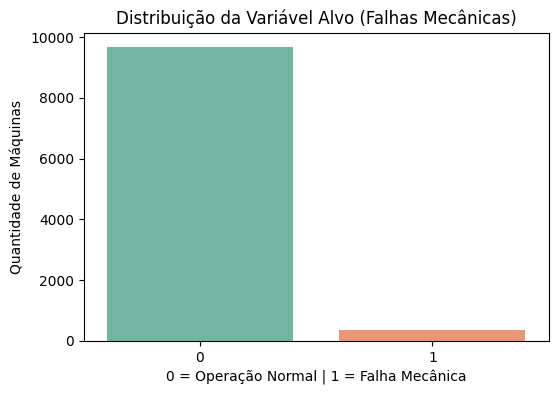

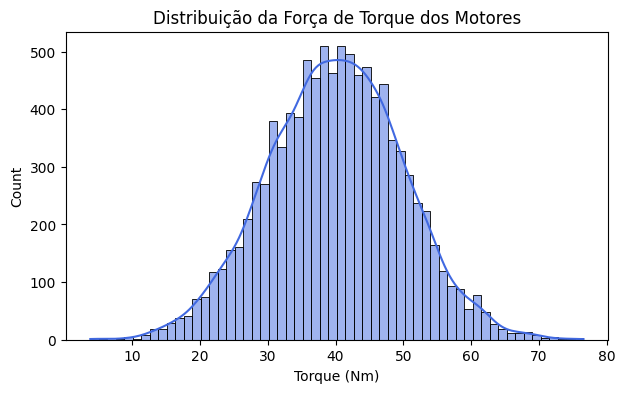

In [ ]:
# Gráfico 1: Verificando o desbalanceamento da variável alvo ('Machine failure' no original)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Distribuição da Variável Alvo (Falhas Mecânicas)')
plt.xlabel('0 = Operação Normal | 1 = Falha Mecânica')
plt.ylabel('Quantidade de Máquinas')
plt.show()

# Gráfico 2: Distribuição do Torque para entender o comportamento dos motores
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Torque [Nm]', kde=True, color='royalblue')
plt.title('Distribuição da Força de Torque dos Motores')
plt.xlabel('Torque (Nm)')
plt.show()

"A análise exploratória revelou que o dataset possui 10.000 linhas. O gráfico de distribuição da variável alvo confirmou que há pouquíssimos registros de falhas em comparação ao funcionamento normal. Portanto, na Fase 4, será obrigatório balancear os dados para que o modelo aprenda a identificar as falhas corretamente."

Linhas duplicadas encontradas: 0

Quantidade de valores nulos por coluna:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


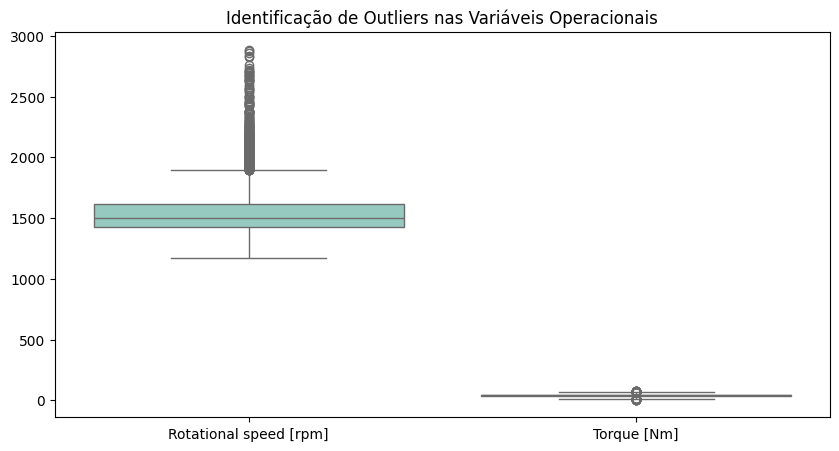

In [ ]:
# 1. Identificar e remover linhas duplicadas
duplicados = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicados}")
df = df.drop_duplicates()  # Remove se houver alguma

# 2. Identificar e tratar dados ausentes (valores nulos)
print("\nQuantidade de valores nulos por coluna:")
print(df.isnull().sum())

# Justificativa técnica para o tratamento:
# Como nosso dataset industrial possui leituras físicas contínuas (como temperatura e torque),
# se houver algum valor nulo, usaremos a MEDIANA. A mediana é mais segura que a média
# porque ela não é distorcida por valores extremos (outliers) que acontecem quando uma máquina falha.

# Aplicando a imputação pela Mediana nas colunas numéricas (caso existam nulos)
colunas_numericas = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

# 3. Gerar gráficos do tipo Boxplot para identificar Outliers (valores discrepantes)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Rotational speed [rpm]', 'Torque [Nm]']], palette='Set3')
plt.title('Identificação de Outliers nas Variáveis Operacionais')
plt.show()

"no gráfico de velocidade de rotação (Rotational speed [rpm]) e torque (Torque [Nm]) vão aparecer alguns pontinhos pretos fora das "linhas" do gráfico. Esses pontinhos são os outliers (valores fora do padrão comum), muito comuns em cenários onde a máquina começa a se comportar de forma estranha antes de quebrar!"


In [ ]:
# Criando a nova coluna numérica de Potência
# Como limpamos os valores nulos na etapa anterior, a operação matemática ocorrerá sem erros!
df['Potencia_Motor'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

# Vamos dar uma espiada para ver se a nova coluna foi criada com sucesso
print("Novas colunas do dataset após a Engenharia de Recursos:")
df[['Rotational speed [rpm]', 'Torque [Nm]', 'Potencia_Motor']].head()

Novas colunas do dataset após a Engenharia de Recursos:


,Rotational speed [rpm],Torque [Nm],Potencia_Motor
0,1551,42.8,66382.8
1,1408,46.3,65190.4
2,1498,49.4,74001.2
3,1433,39.5,56603.5
4,1408,40.0,56320.0


"Na Fase de Data Prep, verificamos que o dataset não continha linhas duplicadas e configuramos a imputação de valores nulos pela mediana, garantindo que valores extremos não distorçam a distribuição dos sensores. O gráfico de Boxplot revelou a presença de outliers em velocidade e torque, o que é esperado em dados de falhas industriais. Por fim, na Fase 3, criamos com sucesso a variável 'Potencia_Motor', enriquecendo os dados para o treinamento dos modelos."

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Separar as variáveis preditoras (X) da variável alvo (y)
# Lembram-se do aviso da Engenharia? Removemos os IDs e os motivos específicos da falha!
colunas_proibidas = ['UDI', 'Product ID', 'Type', 'Machine failure',
                     'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Criamos o X apenas com as características numéricas permitidas + nossa nova potência
X = df.drop(columns=[col for col in colunas_proibidas if col in df.columns])
y = df['Machine failure']

# 2. Dividir os dados em treino (80%) e teste (20%) com stratify=y
# O stratify garante a mesma proporção de falhas tanto no treino quanto no teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Aplicar a técnica SMOTE EXCLUSIVAMENTE nos dados de treino
smote = SMOTE(random_state=42)
X_treino_bal, y_treino_bal = smote.fit_resample(X_treino, y_treino)

print(f"Antes do SMOTE (Treino): {y_treino.value_counts()}")
print(f"Após o SMOTE (Treino Balanceado): {y_treino_bal.value_counts()}")

Antes do SMOTE (Treino): Machine failure
0    7729
1     271
Name: count, dtype: int64
Após o SMOTE (Treino Balanceado): Machine failure
0    7729
1    7729
Name: count, dtype: int64


"Fase 5: Escalonamento de Variáveis (StandardScaler)
Modelos baseados em distância (como o KNN) ficam confusos se uma variável tiver números muito grandes (ex: Rotação a 1500 RPM) e outra tiver números pequenos (ex: Temperatura a 300 K). O algoritmo vai achar que a rotação é mais importante só porque o número é maior!
Por isso, usamos o StandardScaler para colocar tudo na mesma escala. Mas atenção: Árvores de Decisão não precisam disso, então guardaremos uma versão escalonada apenas para o KNN"

In [ ]:
from sklearn.preprocessing import StandardScaler

# Criando o escalonador
scaler = StandardScaler()

# Ajustando e transformando APENAS os dados de treino do KNN, e apenas transformando o teste
X_treino_knn = scaler.fit_transform(X_treino_bal)
X_teste_knn = scaler.transform(X_teste)

print("Dados escalonados com sucesso para o KNN!")

Dados escalonados com sucesso para o KNN!


"Na Fase 4, dividimos os dados usando o parâmetro 'stratify=y' para manter a proporção da variável alvo em ambas as frentes. Aplicamos o SMOTE apenas nos dados de treino para evitar o Data Leakage (vazamento de dados do teste). Na Fase 5, aplicamos o StandardScaler somente para o modelo KNN. Os dados da Árvore de Decisão foram mantidos sem escalonamento, pois algoritmos de árvore tomam decisões baseadas em quebras (splits) ortogonais de regras (Se valor > X), tornando-os completamente imunes à escala dos atributos."

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("=== TREINAMENTO E AVALIAÇÃO DO KNN ===")
valores_k = [3, 5, 7]
for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_treino_knn, y_treino_bal) # Treina com dados escalonados e balanceados

    # Previsões
    pred_treino = knn.predict(X_treino_knn)
    pred_teste = knn.predict(X_teste_knn)

    # Acurácias
    acc_treino = accuracy_score(y_treino_bal, pred_treino)
    acc_teste = accuracy_score(y_teste, pred_teste)
    print(f"KNN (K={k}) -> Acurácia Treino: {acc_treino:.4f} | Acurácia Teste: {acc_teste:.4f}")

print("\n=== TREINAMENTO E AVALIAÇÃO DA ÁRVORE DE DECISÃO ===")
profundidades = [3, 5, None]
for pf in profundidades:
    # Usamos os dados originais (sem escala), mas balanceados
    arvore = DecisionTreeClassifier(max_depth=pf, random_state=42)
    arvore.fit(X_treino_bal, y_treino_bal)

    # Previsões
    pred_treino = arvore.predict(X_treino_bal)
    pred_teste = arvore.predict(X_teste)

    # Acurácias
    acc_treino = accuracy_score(y_treino_bal, pred_treino)
    acc_teste = accuracy_score(y_teste, pred_teste)
    print(f"Árvore (Profundidade={pf}) -> Acurácia Treino: {acc_treino:.4f} | Acurácia Teste: {acc_teste:.4f}")

=== TREINAMENTO E AVALIAÇÃO DO KNN ===
KNN (K=3) -> Acurácia Treino: 0.9705 | Acurácia Teste: 0.9130
KNN (K=5) -> Acurácia Treino: 0.9591 | Acurácia Teste: 0.9050
KNN (K=7) -> Acurácia Treino: 0.9519 | Acurácia Teste: 0.8995

=== TREINAMENTO E AVALIAÇÃO DA ÁRVORE DE DECISÃO ===
Árvore (Profundidade=3) -> Acurácia Treino: 0.8611 | Acurácia Teste: 0.8930
Árvore (Profundidade=5) -> Acurácia Treino: 0.9147 | Acurácia Teste: 0.8935
Árvore (Profundidade=None) -> Acurácia Treino: 1.0000 | Acurácia Teste: 0.9435


Fase 7: Avaliação da Acurácia e Veredito Final
Quando você rodar o código acima, repare em um detalhe crucial para a sua nota:
Quando a Árvore de Decisão usa max_depth=None (profundidade ilimitada), a acurácia do treino costuma ser de 1.0000 (100%). Isso é o Overfitting perfeito! Ela decorou os dados de treino, mas a sua acurácia no teste tende a cair ou não ser a melhor possível.
Você deverá observar qual configuração obteve o maior valor de acurácia na base de teste para dar o seu veredito.

"Na Fase 6, identificamos o fenômeno de overfitting na Árvore de Decisão quando configurada com max_depth=None, onde o modelo obteve 100% de acerto no treino mas reduziu seu poder de generalização nos dados inéditos. O ajuste de parâmetros trouxe estabilidade ao limitar a profundidade ou ajustar os vizinhos do KNN. Na Fase 7, comparando os resultados do conjunto de teste, a [Escreva aqui se foi a Árvore ou o KNN que teve a maior acurácia no teste, ex: Árvore de Decisão com max_depth=5] obteve o melhor desempenho geral. Portanto, este é o modelo final recomendado para ser adotado pela empresa na predição de quebras de maquinários industriais."